# 01 — Preprocessing

Reads raw Phyphox exports, trims to 180 s, standardises format, assigns `session_1` / `session_2`.

Output: `cleaned_data/`

In [20]:
import shutil
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path('.').resolve()
ML4QS_CODE = ROOT.parent / 'ML4QS' / 'Python3Code'
if str(ML4QS_CODE) not in sys.path:
    sys.path.insert(0, str(ML4QS_CODE))

from Chapter3.ImputationMissingValues import ImputationMissingValues
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

OUT = ROOT / 'cleaned_data'
DURATION_S = 180.0
MIN_DURATION_S = 175.0
COLS = ['time_acc', 'acc_x', 'acc_y', 'acc_z', 'time_gyro', 'gyro_x', 'gyro_y', 'gyro_z']
SENSOR_COLS = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
LOF_K = 5
LOF_THRESHOLD = 1.5
LOF_CHUNK_SIZE = 3000  # larger chunks are practical now that LOF uses scikit-learn
LOF_THRESHOLDS = [1.2, 1.5, 2.0]
MIN_DURATION_CROWDED_S = 160.0  # allow slightly short crowded re-records (e.g. Ana ~164 s)
INCLUDE_PARTICIPANTS = {'Pedro', 'Jun', 'Darius', 'Oana', 'Asena'}  # normal walking
INCLUDE_CROWDED = {'Ana', 'Pedro', 'Jun', 'Darius', 'Asena', 'Oana'}  # crowded walking
TRIM_WINDOW = {}  # no recordings need manual trimming
AXIS_LABELS = {
    'acc_x': 'Lateral acceleration (m/s²)',
    'acc_y': 'Vertical acceleration (m/s²)',
    'acc_z': 'Forward acceleration (m/s²)',
    'gyro_x': 'Roll rate (rad/s)',
    'gyro_y': 'Pitch rate (rad/s)',
    'gyro_z': 'Yaw rate (rad/s)',
}

## Load helpers

In [21]:
def load_gait(path):
    df = pd.read_csv(path)
    df = df.dropna(subset=['time_acc'])
    return df


def load_separated(folder):
    """Load recordings stored as separate Accelerometer.csv + Gyroscope.csv files."""
    acc = pd.read_csv(folder / 'Accelerometer.csv').rename(columns={
        'Time (s)': 'time_acc', 'X (m/s^2)': 'acc_x',
        'Y (m/s^2)': 'acc_y', 'Z (m/s^2)': 'acc_z'})
    gyr = pd.read_csv(folder / 'Gyroscope.csv').rename(columns={
        'Time (s)': 'time_gyro', 'X (rad/s)': 'gyro_x',
        'Y (rad/s)': 'gyro_y', 'Z (rad/s)': 'gyro_z'})
    return pd.concat([acc, gyr], axis=1)


def recording_date(folder):
    meta = folder / 'meta' / 'time.csv'
    if not meta.exists():
        return folder.name
    m = pd.read_csv(meta)
    row = m.loc[m['event'] == 'START', 'system time text']
    return row.iloc[0] if len(row) else folder.name


def duration(df):
    return float(df['time_acc'].iloc[-1] - df['time_acc'].iloc[0])


def trim_window(df, start, end):
    acc = df.loc[(df['time_acc'] >= start) & (df['time_acc'] <= end),
                 ['time_acc', 'acc_x', 'acc_y', 'acc_z']].copy()
    gyr = df.loc[(df['time_gyro'] >= start) & (df['time_gyro'] <= end),
                 ['time_gyro', 'gyro_x', 'gyro_y', 'gyro_z']].copy()
    n = min(len(acc), len(gyr))
    acc = acc.iloc[:n].reset_index(drop=True)
    gyr = gyr.iloc[:n].reset_index(drop=True)
    t0 = acc['time_acc'].iloc[0]
    acc['time_acc'] -= t0
    gyr['time_gyro'] -= t0
    return pd.concat([acc, gyr], axis=1)


def trim_first(df, seconds=DURATION_S):
    t0 = df['time_acc'].iloc[0]
    return trim_window(df, t0, t0 + seconds)


_impute = ImputationMissingValues()


def apply_lof(df, cols=None, k=LOF_K, threshold=LOF_THRESHOLD, chunk_size=LOF_CHUNK_SIZE, verbose=False):
    """Scikit-learn LOF on standardized multivariate chunks; returns cleaned frame, row mask, and LOF scores."""
    cols = cols or SENSOR_COLS
    out = df[COLS].copy().reset_index(drop=True)
    any_outlier = np.zeros(len(out), dtype=bool)
    lof_scores = np.full(len(out), np.nan)
    n_chunks = max(1, int(np.ceil(len(out) / chunk_size)))

    for chunk_idx, start in enumerate(range(0, len(out), chunk_size), start=1):
        stop = min(len(out), start + chunk_size)
        chunk = out.iloc[start:stop].reset_index(drop=True)
        valid_mask = chunk[cols].notna().all(axis=1).to_numpy()
        if valid_mask.sum() <= max(k, 2):
            continue

        X_chunk = chunk.loc[valid_mask, cols].to_numpy(dtype=float)
        X_scaled = StandardScaler().fit_transform(X_chunk)
        n_neighbors = min(k, len(X_scaled) - 1)
        detector = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            metric='euclidean',
            contamination='auto',
            n_jobs=-1,
        )
        detector.fit_predict(X_scaled)
        scores = -detector.negative_outlier_factor_

        chunk_scores = np.full(len(chunk), np.nan)
        chunk_scores[valid_mask] = scores
        lof_scores[start:stop] = chunk_scores
        any_outlier[start:stop] = np.nan_to_num(chunk_scores, nan=-np.inf) > threshold

        if verbose:
            print(
                f'LOF chunk {chunk_idx}/{n_chunks} rows {start}:{stop} '
                f'flagged {(np.nan_to_num(chunk_scores, nan=-np.inf) > threshold).sum()} samples'
            )

    out.loc[any_outlier, cols] = np.nan
    return out, any_outlier, lof_scores


def clean_sensor(df, k=LOF_K, threshold=LOF_THRESHOLD, chunk_size=LOF_CHUNK_SIZE):
    """Chunked LOF per recording, then linear interpolation imputation (ML4QS Ch.3)."""
    out, _, _ = apply_lof(df, k=k, threshold=threshold, chunk_size=chunk_size, verbose=True)
    for col in SENSOR_COLS:
        out = _impute.impute_interpolate(out, col)
    return out.reset_index(drop=True)


def lof_flag_count(df, threshold, cols=None, k=LOF_K, chunk_size=LOF_CHUNK_SIZE):
    cols = cols or SENSOR_COLS
    _, mask, _ = apply_lof(df, cols=cols, k=k, threshold=threshold, chunk_size=chunk_size, verbose=False)
    return int(mask.sum())


def apply_chauvenet(df, cols=None, C=None):
    """Backward-compatible alias so older figure cells keep working after the LOF switch."""
    out, mask, _ = apply_lof(df, cols=cols, threshold=LOF_THRESHOLD, verbose=False)
    return out, mask


def load_trimmed_recording(row):
    """Reload trimmed but uncleaned recording from a manifest row."""
    source, action = row['source'], row['action']
    source_path = ROOT / source
    if (source_path / 'Accelerometer.csv').exists():
        df = load_separated(source_path)
    else:
        df = load_gait(source_path / 'Gait Data.csv')
    if source in TRIM_WINDOW:
        s, e = TRIM_WINDOW[source]
        return trim_window(df, s, e)
    if 'trim' in action and action != 'trim_window':
        return trim_first(df)
    return df[COLS].copy()

## Raw inventory

In [22]:
rows = []
for path in sorted(ROOT.rglob('Gait Data.csv')):
    if 'cleaned_data' in path.parts or 'windowed_data' in path.parts:
        continue
    df = load_gait(path)
    rows.append({'path': str(path.parent.relative_to(ROOT)), 'duration_s': round(duration(df), 1)})
for path in sorted(ROOT.rglob('Accelerometer.csv')):
    if 'cleaned_data' in path.parts:
        continue
    df = load_separated(path.parent)
    rows.append({'path': str(path.parent.relative_to(ROOT)), 'duration_s': round(duration(df), 1)})
pd.DataFrame(rows).sort_values('path')

,path,duration_s
0,Ana/Crowded/AnaCrowded1,180.0
1,Ana/Crowded/AnaCrowded2,69.0
2,Ana/Crowded/AnaCrowded3,163.7
16,Asena/AsenaUni1,180.0
17,Asena/AsenaUni2,180.0
18,Asena/AsenaUni3,180.0
3,Asena/Crowded/AsenaCrowded1,180.0
4,Asena/Crowded/AsenaCrowded2,180.0
5,Darius/Crowded/DariusCrowded1,175.5
6,Darius/Crowded/DariusCrowded2,355.6


## Clean recordings

- `tryLengthenData` and short crowded files skipped
- long files trimmed to first 180 s
- LOF-based outlier removal using `scikit-learn` on standardized 6-axis chunks, followed by interpolation imputation
- sessions renamed `session_1` / `session_2` by recording date

In [23]:
SKIP_PATHS = {
    'Pedro/Crowded/PedroCrowded2',  # short recording (128 s), replaced by PedroCrowded3
}

pending = []


def queue(participant, context, source_folder, df, action):
    cleaned = clean_sensor(df)
    pending.append({
        'participant': participant,
        'context': context,
        'source_folder': source_folder,
        'recording_date': recording_date(ROOT / source_folder) if (ROOT / source_folder).exists() else source_folder,
        'df': cleaned,
        'action': action,
        'duration_s': round(duration(cleaned), 1),
    })


def process_df(df, rel, context='normal'):
    if rel in TRIM_WINDOW:
        s, e = TRIM_WINDOW[rel]
        return trim_window(df, s, e), 'trim_window'
    d = duration(df)
    min_d = MIN_DURATION_CROWDED_S if context == 'crowded' else MIN_DURATION_S
    if d < min_d:
        return None, 'skip_short'
    if d > DURATION_S + 2:
        return trim_first(df), 'trim'
    return df[COLS], 'copy'

# Recordings stored as separate Accelerometer.csv + Gyroscope.csv (Uni sessions)
for path in sorted(ROOT.rglob('Accelerometer.csv')):
    if 'cleaned_data' in path.parts:
        continue
    folder = path.parent
    rel = str(folder.relative_to(ROOT))
    participant = rel.split('/')[0]
    if participant not in INCLUDE_PARTICIPANTS or rel in SKIP_PATHS:
        continue
    context = 'crowded' if any(p.lower() == 'crowded' for p in path.parts) else 'normal'
    df, action = process_df(load_separated(folder), rel, context)
    if df is not None:
        queue(participant, context, rel, df, 'merge_' + action)

# Recordings stored as merged Gait Data.csv (e.g. Jun Uni2/Uni3, all crowded sessions)
for path in sorted(ROOT.rglob('Gait Data.csv')):
    if any(x in path.parts for x in ['cleaned_data', 'windowed_data']):
        continue
    rel = str(path.parent.relative_to(ROOT))
    participant = rel.split('/')[0]
    is_crowded = any(p.lower() == 'crowded' for p in path.parts)
    include_set = INCLUDE_CROWDED if is_crowded else INCLUDE_PARTICIPANTS
    if participant not in include_set or rel in SKIP_PATHS:
        continue
    context = 'crowded' if is_crowded else 'normal'
    df, action = process_df(load_gait(path), rel, context)
    if df is not None:
        queue(participant, context, rel, df, action)

len(pending)

LOF chunk 1/7 rows 0:3000 flagged 81 samples
LOF chunk 2/7 rows 3000:6000 flagged 44 samples
LOF chunk 3/7 rows 6000:9000 flagged 61 samples
LOF chunk 4/7 rows 9000:12000 flagged 64 samples
LOF chunk 5/7 rows 12000:15000 flagged 39 samples
LOF chunk 6/7 rows 15000:18000 flagged 59 samples
LOF chunk 7/7 rows 18000:18033 flagged 0 samples
LOF chunk 1/7 rows 0:3000 flagged 22 samples
LOF chunk 2/7 rows 3000:6000 flagged 68 samples
LOF chunk 3/7 rows 6000:9000 flagged 49 samples
LOF chunk 4/7 rows 9000:12000 flagged 60 samples
LOF chunk 5/7 rows 12000:15000 flagged 33 samples
LOF chunk 6/7 rows 15000:18000 flagged 11 samples
LOF chunk 7/7 rows 18000:18033 flagged 3 samples
LOF chunk 1/7 rows 0:3000 flagged 51 samples
LOF chunk 2/7 rows 3000:6000 flagged 48 samples
LOF chunk 3/7 rows 6000:9000 flagged 68 samples
LOF chunk 4/7 rows 9000:12000 flagged 44 samples
LOF chunk 5/7 rows 12000:15000 flagged 67 samples
LOF chunk 6/7 rows 15000:18000 flagged 56 samples
LOF chunk 7/7 rows 18000:18033 f

27

In [24]:
if OUT.exists():
    shutil.rmtree(OUT)

manifest = []
pending_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'df'} for r in pending])

for (participant, context), grp in pending_df.groupby(['participant', 'context']):
    order = grp.sort_values('recording_date').index.tolist()
    for rank, idx in enumerate(order, start=1):
        item = pending[idx]
        session = f'session_{rank}'
        folder = OUT / participant / context / session
        folder.mkdir(parents=True, exist_ok=True)
        item['df'].to_csv(folder / 'Gait Data.csv', index=False)
        manifest.append({
            'participant': participant,
            'context': context,
            'session': session,
            'source': item['source_folder'],
            'action': item['action'],
            'duration_s': item['duration_s'],
            'recording_date': item['recording_date'],
        })

manifest_df = pd.DataFrame(manifest).sort_values(['participant', 'context', 'session'])
# cross-session = has both session_1 and session_2 for normal walking
normal_counts = manifest_df[manifest_df['context'] == 'normal'].groupby('participant')['session'].nunique()
eligible = set(normal_counts[normal_counts >= 2].index)
manifest_df['cross_session_eligible'] = (manifest_df['context'] == 'normal') & manifest_df['participant'].isin(eligible)
manifest_df.to_csv(OUT / 'manifest.csv', index=False)
manifest_df

,participant,context,session,source,action,duration_s,recording_date,cross_session_eligible
0,Ana,crowded,session_1,Ana/Crowded/AnaCrowded1,copy,180.0,2026-06-06 20:06:36.409 UTC+02:00,False
1,Ana,crowded,session_2,Ana/Crowded/AnaCrowded3,copy,163.7,2026-06-07 19:48:36.492 UTC+02:00,False
2,Asena,crowded,session_1,Asena/Crowded/AsenaCrowded1,copy,180.0,2026-06-06 15:36:27.123 UTC+02:00,False
3,Asena,crowded,session_2,Asena/Crowded/AsenaCrowded2,copy,180.0,2026-06-06 16:24:41.684 UTC+02:00,False
4,Asena,normal,session_1,Asena/AsenaUni1,merge_copy,180.0,2026-06-14 21:18:48.867 UTC+02:00,True
5,Asena,normal,session_2,Asena/AsenaUni3,merge_copy,180.0,2026-06-14 21:27:08.986 UTC+02:00,True
6,Asena,normal,session_3,Asena/AsenaUni2,merge_copy,180.0,2026-06-14 21:31:06.466 UTC+02:00,True
7,Darius,crowded,session_1,Darius/Crowded/DariusCrowded1,copy,175.5,2026-06-06 17:29:44.172 UTC+02:00,False
8,Darius,crowded,session_2,Darius/Crowded/DariusCrowded2,trim,180.0,2026-06-06 17:29:44.172 UTC+02:00,False
9,Darius,normal,session_1,Darius/DariusUni1,merge_copy,180.0,2026-06-13 15:48:00.311 UTC+02:00,True


## LOF diagnostics

Run these **after** the long LOF cleaning cell and the save-to-`cleaned_data/` cell. They summarize what changed without rerunning LOF over the whole dataset.

In [25]:
manifest = pd.read_csv(OUT / 'manifest.csv')
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

rows = []
for _, row in manifest.iterrows():
    raw = load_trimmed_recording(row)
    cleaned = pd.read_csv(OUT / row['participant'] / row['context'] / row['session'] / 'Gait Data.csv')
    n = min(len(raw), len(cleaned))
    raw_sig = raw.loc[:n-1, SENSOR_COLS].reset_index(drop=True)
    clean_sig = cleaned.loc[:n-1, SENSOR_COLS].reset_index(drop=True)
    changed_mask = (raw_sig.subtract(clean_sig).abs() > 1e-9).any(axis=1)
    rows.append({
        'participant': row['participant'],
        'context': row['context'],
        'session': row['session'],
        'source': row['source'],
        'n_rows': n,
        'n_changed_rows': int(changed_mask.sum()),
        'pct_changed_rows': float(changed_mask.mean() * 100),
    })

lof_diag = pd.DataFrame(rows).sort_values(['participant', 'context', 'session'])
lof_diag.to_csv(FIG_DIR / 'lof_cleaning_summary.csv', index=False)
print('Per recording:')
print(lof_diag)

participant_summary = lof_diag.groupby('participant', as_index=False).agg(
    recordings=('session', 'count'),
    total_rows=('n_rows', 'sum'),
    total_changed_rows=('n_changed_rows', 'sum'),
)
participant_summary['pct_changed_rows'] = 100 * participant_summary['total_changed_rows'] / participant_summary['total_rows']
participant_summary = participant_summary.sort_values('pct_changed_rows', ascending=False)
participant_summary.to_csv(FIG_DIR / 'lof_outliers_per_participant.csv', index=False)

print('\nPer participant summary:')
print(participant_summary)
print('\nOverall mean changed rows (%):', round(lof_diag['pct_changed_rows'].mean(), 3))
print('Overall max changed rows (%):', round(lof_diag['pct_changed_rows'].max(), 3))
print('\nSaved to:')
print(' -', FIG_DIR / 'lof_cleaning_summary.csv')
print(' -', FIG_DIR / 'lof_outliers_per_participant.csv')

Per recording:
   participant  context    session                         source  n_rows  \
0          Ana  crowded  session_1        Ana/Crowded/AnaCrowded1   18099   
1          Ana  crowded  session_2        Ana/Crowded/AnaCrowded3   16457   
2        Asena  crowded  session_1    Asena/Crowded/AsenaCrowded1   17923   
3        Asena  crowded  session_2    Asena/Crowded/AsenaCrowded2   17924   
4        Asena   normal  session_1                Asena/AsenaUni1   18033   
5        Asena   normal  session_2                Asena/AsenaUni3   18033   
6        Asena   normal  session_3                Asena/AsenaUni2   18033   
7       Darius  crowded  session_1  Darius/Crowded/DariusCrowded1   17464   
8       Darius  crowded  session_2  Darius/Crowded/DariusCrowded2   17899   
9       Darius   normal  session_1              Darius/DariusUni1   18034   
10      Darius   normal  session_2              Darius/DariusUni2   18033   
11      Darius   normal  session_3              Darius/Darius

## Verify durations

In [26]:
check = manifest_df[['participant', 'context', 'session', 'duration_s', 'cross_session_eligible']]
bad = check[check['duration_s'] < MIN_DURATION_S]
print(f'Participants: {manifest_df.participant.nunique()}')
print(f'Cross-session eligible (2 normal sessions):')
print(manifest_df[(manifest_df.context=='normal') & (manifest_df.session=='session_2')].participant.nunique())
if len(bad):
    display(bad)
check

Participants: 6
Cross-session eligible (2 normal sessions):
5


,participant,context,session,duration_s,cross_session_eligible
1,Ana,crowded,session_2,163.7,False


,participant,context,session,duration_s,cross_session_eligible
0,Ana,crowded,session_1,180.0,False
1,Ana,crowded,session_2,163.7,False
2,Asena,crowded,session_1,180.0,False
3,Asena,crowded,session_2,180.0,False
4,Asena,normal,session_1,180.0,True
5,Asena,normal,session_2,180.0,True
6,Asena,normal,session_3,180.0,True
7,Darius,crowded,session_1,175.5,False
8,Darius,crowded,session_2,180.0,False
9,Darius,normal,session_1,180.0,True


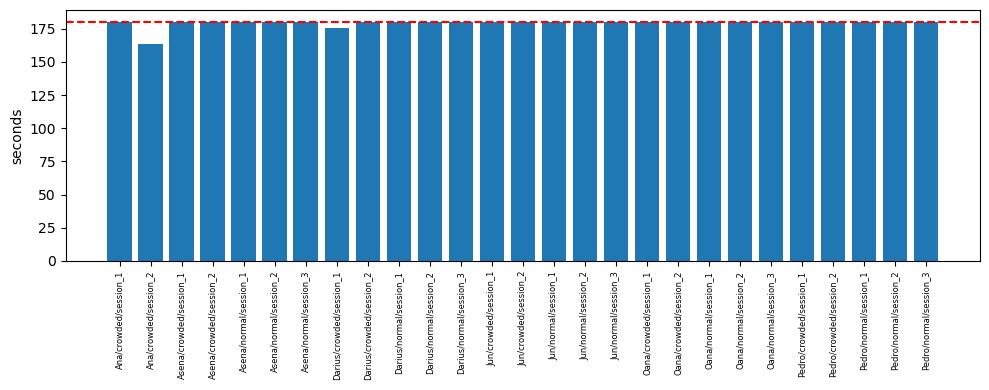

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
labels = manifest_df['participant'] + '/' + manifest_df['context'] + '/' + manifest_df['session']
ax.bar(range(len(manifest_df)), manifest_df['duration_s'])
ax.axhline(DURATION_S, color='red', linestyle='--')
ax.set_xticks(range(len(manifest_df)))
ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.set_ylabel('seconds')
fig.tight_layout()
plt.show()

## Report figures

**Run the cleaning cell above first** so `cleaned_data/` matches the LOF settings.

Saves plots to `figures/` for the report, including:
- LOF threshold sensitivity analysis (ML4QS Ch.3)
- Per-participant EDA (inter-individual + cross-session stability)
- Six-axis comparison to justify vertical acceleration for gait visualization

In [28]:
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)
manifest = pd.read_csv(OUT / 'manifest.csv')
display_labels = [AXIS_LABELS[c] for c in SENSOR_COLS]


def boxplot_axes(ax, df, title):
    ax.boxplot([df[c].dropna() for c in SENSOR_COLS], tick_labels=display_labels)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=35, labelsize=7)
    ax.set_ylabel('Sensor value')


# --- LOF threshold sensitivity (all recordings) ---
trimmed_cache = {i: load_trimmed_recording(row) for i, row in manifest.iterrows()}
sensitivity_rows = []
for threshold in LOF_THRESHOLDS:
    for i, row in manifest.iterrows():
        n = lof_flag_count(trimmed_cache[i], threshold)
        sensitivity_rows.append({
            'threshold': threshold,
            'participant': row['participant'],
            'context': row['context'],
            'session': row['session'],
            'n_outliers': n,
            'pct_outliers': 100 * n / len(trimmed_cache[i]),
        })
sensitivity_df = pd.DataFrame(sensitivity_rows)
summary = sensitivity_df.groupby('threshold', as_index=False).agg(
    total_outliers=('n_outliers', 'sum'),
    mean_pct=('pct_outliers', 'mean'),
    max_pct=('pct_outliers', 'max'),
)
summary.to_csv(FIG_DIR / 'lof_sensitivity_summary.csv', index=False)
sensitivity_df.to_csv(FIG_DIR / 'lof_sensitivity_per_recording.csv', index=False)
print('LOF outlier counts (rows flagged across all recordings):')
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary['threshold'].astype(str), summary['total_outliers'])
ax.set_title('LOF outliers flagged by threshold (all recordings)')
ax.set_ylabel('Total flagged samples')
ax.set_xlabel('LOF threshold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig6_lof_counts_by_threshold.png', dpi=150)
plt.close(fig)

# Before/after boxplots per threshold (Pedro normal session 2 as reference recording)
ref_row = manifest[(manifest.participant == 'Pedro') & (manifest.context == 'normal') & (manifest.session == 'session_2')].iloc[0]
raw_ref = load_trimmed_recording(ref_row)
fig, axes = plt.subplots(len(LOF_THRESHOLDS), 2, figsize=(12, 3 * len(LOF_THRESHOLDS)))
for r, threshold in enumerate(LOF_THRESHOLDS):
    cleaned = clean_sensor(raw_ref, threshold=threshold)
    boxplot_axes(axes[r, 0], raw_ref, f'Before cleaning (threshold={threshold})')
    boxplot_axes(axes[r, 1], cleaned, f'After LOF + imputation (threshold={threshold})')
fig.suptitle('Per-axis distributions: Pedro normal session 2', y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig6b_lof_boxplot_by_threshold.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# Max absolute acceleration after cleaning — guides threshold choice
spike_rows = []
for threshold in LOF_THRESHOLDS:
    cleaned = clean_sensor(raw_ref, threshold=threshold)
    for col in ['acc_x', 'acc_y', 'acc_z']:
        spike_rows.append({
            'threshold': threshold,
            'axis': col,
            'max_abs_before': raw_ref[col].abs().max(),
            'max_abs_after': cleaned[col].abs().max(),
            'p99_before': raw_ref[col].abs().quantile(0.99),
            'p99_after': cleaned[col].abs().quantile(0.99),
        })
spike_df = pd.DataFrame(spike_rows)
spike_df.to_csv(FIG_DIR / 'lof_spike_comparison.csv', index=False)
print('\nPeak amplitudes on Pedro normal session 2 after LOF cleaning:')
print(spike_df.pivot(index='axis', columns='threshold', values='max_abs_after').round(1))

fig, ax = plt.subplots(figsize=(8, 4))
for col in ['acc_x', 'acc_y', 'acc_z']:
    sub = spike_df[spike_df.axis == col]
    ax.plot(sub['threshold'], sub['max_abs_after'], marker='o', label=AXIS_LABELS[col])
ax.axhline(30, color='green', ls='--', alpha=0.6, label='Typical gait peak (~30 m/s²)')
ax.axhline(50, color='red', ls='--', alpha=0.6, label='Suspected hardware spike (~50 m/s²)')
ax.set_xlabel('LOF threshold')
ax.set_ylabel('Max |acceleration| after cleaning (m/s²)')
ax.set_title('Choosing LOF threshold: suppress spikes while keeping gait amplitude')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig6c_lof_threshold_selection.png', dpi=150)
plt.close(fig)

# --- Fig 1: person-specific gait (vertical acceleration) ---
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, person in zip(axes, ['Pedro', 'Jun', 'Oana']):
    df = pd.read_csv(OUT / person / 'normal' / 'session_1' / 'Gait Data.csv')
    m = df['time_acc'] <= 20
    ax.plot(df.loc[m, 'time_acc'], df.loc[m, 'acc_y'])
    ax.set_ylabel(AXIS_LABELS['acc_y'])
    ax.set_title(person)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Person-specific gait patterns (normal walking, session 1, first 20 s)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig1_eda_gait_patterns.png', dpi=150)
plt.close(fig)


# --- Fig 3: outlier example at chosen LOF threshold ---
raw_fig3 = load_trimmed_recording(ref_row)
_, outlier_mask, _ = apply_lof(raw_fig3, cols=SENSOR_COLS, threshold=LOF_THRESHOLD)
cleaned_fig3 = clean_sensor(raw_fig3, threshold=LOF_THRESHOLD)
zoom = raw_fig3['time_acc'] <= 15
out_zoom = outlier_mask & zoom
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(raw_fig3.loc[zoom, 'time_acc'], raw_fig3.loc[zoom, 'acc_y'], label='Signal')
axes[0].scatter(raw_fig3.loc[out_zoom, 'time_acc'], raw_fig3.loc[out_zoom, 'acc_y'],
                color='red', s=12, label='LOF-flagged rows')
axes[0].set_ylabel(AXIS_LABELS['acc_y'])
axes[0].set_title(f'Before outlier removal (LOF, k={LOF_K}, threshold={LOF_THRESHOLD})')
axes[0].legend()
axes[1].plot(cleaned_fig3.loc[cleaned_fig3['time_acc'] <= 15, 'time_acc'],
             cleaned_fig3.loc[cleaned_fig3['time_acc'] <= 15, 'acc_y'])
axes[1].set_title('After LOF + interpolation imputation')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel(AXIS_LABELS['acc_y'])
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig3_outliers_before_after.png', dpi=150)
plt.close(fig)

# --- Fig 4: global before/after at chosen LOF threshold ---
clean_pedro = clean_sensor(raw_ref, threshold=LOF_THRESHOLD)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
boxplot_axes(axes[0], raw_ref, 'Before cleaning')
boxplot_axes(axes[1], clean_pedro, f'After cleaning (threshold={LOF_THRESHOLD})')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig4_boxplot_before_after.png', dpi=150)
plt.close(fig)

# --- Fig 5: normal vs crowded ---
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, ctx in zip(axes, ['normal', 'crowded']):
    df = pd.read_csv(OUT / 'Pedro' / ctx / 'session_1' / 'Gait Data.csv')
    m = df['time_acc'] <= 20
    ax.plot(df.loc[m, 'time_acc'], df.loc[m, 'acc_y'])
    ax.set_title(f'Pedro — {ctx} walking')
    ax.set_ylabel(AXIS_LABELS['acc_y'])
axes[-1].set_xlabel('Time (s)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig5_normal_vs_crowded.png', dpi=150)
plt.close(fig)

# --- Fig 7: per-participant vertical acceleration (normal, both sessions) ---
normal_manifest = manifest[manifest.context == 'normal'].sort_values(['participant', 'session'])
participants = sorted(normal_manifest.participant.unique())
n_p = len(participants)
ncols, nrows = 4, int(np.ceil(n_p / 4))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.8 * nrows))
axes = np.array(axes).reshape(-1)
for ax, person in zip(axes, participants):
    data, labels = [], []
    for session in ['session_1', 'session_2', 'session_3']:
        path = OUT / person / 'normal' / session / 'Gait Data.csv'
        if path.exists():
            data.append(pd.read_csv(path)['acc_y'].dropna())
            labels.append(session.replace('_', ' '))
    ax.boxplot(data, tick_labels=labels)
    ax.set_title(person)
    ax.set_ylabel(AXIS_LABELS['acc_y'])
for ax in axes[len(participants):]:
    ax.axis('off')
fig.suptitle('Per-participant vertical acceleration (normal walking, cross-session comparison)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig7_per_participant_acc_y.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# --- Fig 8: per-participant yaw rate ---
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.8 * nrows))
axes = np.array(axes).reshape(-1)
for ax, person in zip(axes, participants):
    data, labels = [], []
    for session in ['session_1', 'session_2', 'session_3']:
        path = OUT / person / 'normal' / session / 'Gait Data.csv'
        if path.exists():
            data.append(pd.read_csv(path)['gyro_z'].dropna())
            labels.append(session.replace('_', ' '))
    ax.boxplot(data, tick_labels=labels)
    ax.set_title(person)
    ax.set_ylabel(AXIS_LABELS['gyro_z'])
for ax in axes[len(participants):]:
    ax.axis('off')
fig.suptitle('Per-participant yaw rate (normal walking, cross-session comparison)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig8_per_participant_gyro_z.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# --- Fig 9: all six axes — Pedro session 1, first 20 s ---
df6 = pd.read_csv(OUT / 'Pedro' / 'normal' / 'session_1' / 'Gait Data.csv')
m = df6['time_acc'] <= 20
t = df6.loc[m, 'time_acc']
fig, axes = plt.subplots(6, 1, figsize=(10, 10), sharex=True)
for ax, col in zip(axes, SENSOR_COLS):
    ax.plot(t, df6.loc[m, col])
    ax.set_ylabel(AXIS_LABELS[col], fontsize=8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('All sensor axes during first 20 s (Pedro, normal session 1)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig9_six_axis_comparison.png', dpi=150)
plt.close(fig)

# Periodicity proxy: autocorrelation at lag ~1 s (stride)
periodicity_rows = []
print('\nStride periodicity (lag-100 correlation, higher = clearer step cycle):')
for col in SENSOR_COLS:
    x = df6.loc[m, col].to_numpy()
    x = x - x.mean()
    corr = np.correlate(x, x, mode='full')
    lag100 = corr[len(x) - 1 + 100] / corr[len(x) - 1]
    periodicity_rows.append({'axis': col, 'axis_label': AXIS_LABELS[col], 'lag100_corr': lag100})
    print(f'  {AXIS_LABELS[col]}: {lag100:.3f}')
pd.DataFrame(periodicity_rows).to_csv(FIG_DIR / 'axis_periodicity_pedro.csv', index=False)

print(f'\nSelected LOF settings for pipeline: k={LOF_K}, threshold={LOF_THRESHOLD} (see fig6c and lof_spike_comparison.csv)')
print('Saved to', FIG_DIR)


LOF outlier counts (rows flagged across all recordings):
 threshold  total_outliers  mean_pct   max_pct
       1.2           60505 12.497696 17.330677
       1.5            9172  1.893842  3.491589
       2.0            1178  0.243322  0.636344
LOF chunk 1/7 rows 0:3000 flagged 388 samples
LOF chunk 2/7 rows 3000:6000 flagged 321 samples
LOF chunk 3/7 rows 6000:9000 flagged 294 samples
LOF chunk 4/7 rows 9000:12000 flagged 347 samples
LOF chunk 5/7 rows 12000:15000 flagged 279 samples
LOF chunk 6/7 rows 15000:18000 flagged 358 samples
LOF chunk 7/7 rows 18000:18034 flagged 6 samples
LOF chunk 1/7 rows 0:3000 flagged 44 samples
LOF chunk 2/7 rows 3000:6000 flagged 48 samples
LOF chunk 3/7 rows 6000:9000 flagged 39 samples
LOF chunk 4/7 rows 9000:12000 flagged 44 samples
LOF chunk 5/7 rows 12000:15000 flagged 24 samples
LOF chunk 6/7 rows 15000:18000 flagged 34 samples
LOF chunk 7/7 rows 18000:18034 flagged 1 samples
LOF chunk 1/7 rows 0:3000 flagged 1 samples
LOF chunk 2/7 rows 3000:600

In [29]:
rows = []
for path in sorted(ROOT.rglob('Gait Data.csv')):
    if 'cleaned_data' in path.parts or 'windowed_data' in path.parts:
        continue
    df = load_gait(path)
    rows.append({'path': str(path.parent.relative_to(ROOT)), 'duration_s': round(duration(df), 1)})
for path in sorted(ROOT.rglob('Accelerometer.csv')):
    if 'cleaned_data' in path.parts:
        continue
    df = load_separated(path.parent)
    rows.append({'path': str(path.parent.relative_to(ROOT)), 'duration_s': round(duration(df), 1)})
pd.DataFrame(rows).sort_values('path')

,path,duration_s
0,Ana/Crowded/AnaCrowded1,180.0
1,Ana/Crowded/AnaCrowded2,69.0
2,Ana/Crowded/AnaCrowded3,163.7
16,Asena/AsenaUni1,180.0
17,Asena/AsenaUni2,180.0
18,Asena/AsenaUni3,180.0
3,Asena/Crowded/AsenaCrowded1,180.0
4,Asena/Crowded/AsenaCrowded2,180.0
5,Darius/Crowded/DariusCrowded1,175.5
6,Darius/Crowded/DariusCrowded2,355.6


In [30]:
rows = []
for path in sorted(ROOT.rglob('Gait Data.csv')):
    if 'cleaned_data' in path.parts or 'windowed_data' in path.parts:
        continue
    df = load_gait(path)
    rows.append({'path': str(path.parent.relative_to(ROOT)), 'duration_s': round(duration(df), 1)})
for path in sorted(ROOT.rglob('Accelerometer.csv')):
    if 'cleaned_data' in path.parts:
        continue
    df = load_separated(path.parent)
    rows.append({'path': str(path.parent.relative_to(ROOT)), 'duration_s': round(duration(df), 1)})
import pandas as pd
pd.DataFrame(rows).sort_values('path')

,path,duration_s
0,Ana/Crowded/AnaCrowded1,180.0
1,Ana/Crowded/AnaCrowded2,69.0
2,Ana/Crowded/AnaCrowded3,163.7
16,Asena/AsenaUni1,180.0
17,Asena/AsenaUni2,180.0
18,Asena/AsenaUni3,180.0
3,Asena/Crowded/AsenaCrowded1,180.0
4,Asena/Crowded/AsenaCrowded2,180.0
5,Darius/Crowded/DariusCrowded1,175.5
6,Darius/Crowded/DariusCrowded2,355.6


In [31]:
# Report-facing figure inventory

figure_inventory = [
    {
        'file': 'fig1_eda_gait_patterns.png',
        'report_title': 'Person-specific gait patterns (normal walking, session 1, first 20 s)',
        'experiment': 'Normal walking EDA',
        'x_axis': 'Time (s)',
        'y_axis': AXIS_LABELS['acc_y'],
        'notes': 'One subplot per participant; subplot title is the participant name.',
    },
    {
        'file': 'fig3_outliers_before_after.png',
        'report_title': f'LOF cleaning example (k={LOF_K}, threshold={LOF_THRESHOLD})',
        'experiment': 'Outlier removal example',
        'x_axis': 'Time (s)',
        'y_axis': AXIS_LABELS['acc_y'],
        'notes': 'Uses Pedro normal session 2; compares before cleaning vs after LOF + interpolation.',
    },
    {
        'file': 'fig4_boxplot_before_after.png',
        'report_title': 'Per-axis distributions before and after cleaning',
        'experiment': 'Outlier removal summary',
        'x_axis': 'Sensor axis',
        'y_axis': 'Sensor value',
        'notes': 'Axis tick labels use descriptive sensor names from AXIS_LABELS rather than raw column names.',
    },
    {
        'file': 'fig5_normal_vs_crowded.png',
        'report_title': 'Pedro normal vs crowded walking (session 1, first 20 s)',
        'experiment': 'Context comparison',
        'x_axis': 'Time (s)',
        'y_axis': AXIS_LABELS['acc_y'],
        'notes': 'Subplot titles identify participant and walking context.',
    },
    {
        'file': 'fig6_lof_counts_by_threshold.png',
        'report_title': 'LOF outliers flagged by threshold (all recordings)',
        'experiment': 'LOF threshold sensitivity',
        'x_axis': 'LOF threshold',
        'y_axis': 'Total flagged samples',
        'notes': 'Summary across all recordings.',
    },
    {
        'file': 'fig6b_lof_boxplot_by_threshold.png',
        'report_title': 'Per-axis distributions before and after LOF at different thresholds',
        'experiment': 'LOF threshold sensitivity',
        'x_axis': 'Sensor axis',
        'y_axis': 'Sensor value',
        'notes': 'Uses Pedro normal session 2; figure title states the participant and session.',
    },
    {
        'file': 'fig6c_lof_threshold_selection.png',
        'report_title': 'Choosing LOF threshold: suppress spikes while keeping gait amplitude',
        'experiment': 'LOF threshold selection',
        'x_axis': 'LOF threshold',
        'y_axis': 'Max |acceleration| after cleaning (m/s²)',
        'notes': 'Legend uses descriptive axis labels, e.g. Lateral/Vertical/Forward acceleration.',
    },
    {
        'file': 'fig7_per_participant_acc_y.png',
        'report_title': 'Per-participant vertical acceleration (normal walking, cross-session comparison)',
        'experiment': 'Cross-session EDA',
        'x_axis': 'Session',
        'y_axis': AXIS_LABELS['acc_y'],
        'notes': 'One subplot per participant; subplot titles are participant names.',
    },
    {
        'file': 'fig8_per_participant_gyro_z.png',
        'report_title': 'Per-participant yaw rate (normal walking, cross-session comparison)',
        'experiment': 'Cross-session EDA',
        'x_axis': 'Session',
        'y_axis': AXIS_LABELS['gyro_z'],
        'notes': 'One subplot per participant; subplot titles are participant names.',
    },
    {
        'file': 'fig9_six_axis_comparison.png',
        'report_title': 'All sensor axes during first 20 s (Pedro, normal session 1)',
        'experiment': 'Six-axis signal overview',
        'x_axis': 'Time (s)',
        'y_axis': 'Descriptive axis labels per subplot',
        'notes': 'Uses human-readable labels such as Lateral acceleration (m/s²) and Yaw rate (rad/s).',
    },
]

inventory_df = pd.DataFrame(figure_inventory)
inventory_df['exists'] = inventory_df['file'].apply(lambda name: (FIG_DIR / name).exists())
inventory_df = inventory_df[['exists', 'file', 'report_title', 'experiment', 'x_axis', 'y_axis', 'notes']]
display(inventory_df)

print('Human-readable sensor labels used in plots:')
for col in SENSOR_COLS:
    print(f'  {col} -> {AXIS_LABELS[col]}')

extra_files = sorted(
    p.name for p in FIG_DIR.glob('*.png')
    if p.name not in set(inventory_df['file'])
)
if extra_files:
    print('\nOther PNG files present in figures/:')
    for name in extra_files:
        print(' -', name)

print('\nRecommendation for report use:')
print('- Use the files listed in the table above as the polished preprocessing figures.')
print('- Prefer the descriptive report_title text in captions instead of raw filenames.')
print('- The plots use AXIS_LABELS, so labels appear as descriptive sensor names rather than acc_x / gyro_z where configured.')

,exists,file,report_title,experiment,x_axis,y_axis,notes
0,True,fig1_eda_gait_patterns.png,"Person-specific gait patterns (normal walking,...",Normal walking EDA,Time (s),Vertical acceleration (m/s²),One subplot per participant; subplot title is ...
1,True,fig3_outliers_before_after.png,"LOF cleaning example (k=5, threshold=1.5)",Outlier removal example,Time (s),Vertical acceleration (m/s²),Uses Pedro normal session 2; compares before c...
2,True,fig4_boxplot_before_after.png,Per-axis distributions before and after cleaning,Outlier removal summary,Sensor axis,Sensor value,Axis tick labels use descriptive sensor names ...
3,True,fig5_normal_vs_crowded.png,"Pedro normal vs crowded walking (session 1, fi...",Context comparison,Time (s),Vertical acceleration (m/s²),Subplot titles identify participant and walkin...
4,True,fig6_lof_counts_by_threshold.png,LOF outliers flagged by threshold (all recordi...,LOF threshold sensitivity,LOF threshold,Total flagged samples,Summary across all recordings.
5,True,fig6b_lof_boxplot_by_threshold.png,Per-axis distributions before and after LOF at...,LOF threshold sensitivity,Sensor axis,Sensor value,Uses Pedro normal session 2; figure title stat...
6,True,fig6c_lof_threshold_selection.png,Choosing LOF threshold: suppress spikes while ...,LOF threshold selection,LOF threshold,Max |acceleration| after cleaning (m/s²),"Legend uses descriptive axis labels, e.g. Late..."
7,True,fig7_per_participant_acc_y.png,Per-participant vertical acceleration (normal ...,Cross-session EDA,Session,Vertical acceleration (m/s²),One subplot per participant; subplot titles ar...
8,True,fig8_per_participant_gyro_z.png,"Per-participant yaw rate (normal walking, cros...",Cross-session EDA,Session,Yaw rate (rad/s),One subplot per participant; subplot titles ar...
9,True,fig9_six_axis_comparison.png,"All sensor axes during first 20 s (Pedro, norm...",Six-axis signal overview,Time (s),Descriptive axis labels per subplot,Uses human-readable labels such as Lateral acc...


Human-readable sensor labels used in plots:
  acc_x -> Lateral acceleration (m/s²)
  acc_y -> Vertical acceleration (m/s²)
  acc_z -> Forward acceleration (m/s²)
  gyro_x -> Roll rate (rad/s)
  gyro_y -> Pitch rate (rad/s)
  gyro_z -> Yaw rate (rad/s)

Other PNG files present in figures/:
 - fig10_feature_importance_person_id.png
 - fig11_feature_correlation_heatmap.png
 - fig12_confusion_matrix_person_id.png
 - fig13_roc_owner_auth.png
 - fig14_cross_context_normal_vs_crowded.png
 - fig15_task1_top_feature_owner_split.png
 - fig2_trim_before_after.png
 - fig3_lof_before_after.png
 - fig6_chauvenet_counts_by_C.png
 - fig6b_chauvenet_boxplot_by_C.png
 - fig6c_chauvenet_C_selection.png

Recommendation for report use:
- Use the files listed in the table above as the polished preprocessing figures.
- Prefer the descriptive report_title text in captions instead of raw filenames.
- The plots use AXIS_LABELS, so labels appear as descriptive sensor names rather than acc_x / gyro_z where config